# Loan Process Analytics

Анализ процесса выдачи кредита на основе BPIC 2017.

Данные: событийный лог голландского банка. 31 413 заявок, 1 202 267 событий. Каждое событие — этап процесса с временной меткой, исполнителем и каналом.

Задача: найти узкие места в процессе — где заявки задерживаются, где клиенты отваливаются, какие этапы работают неэффективно.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pm4py
from pathlib import Path

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
%matplotlib inline



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




In [2]:
DATA_PATH = Path('../data/BPI Challenge 2017.xes')
print(f"Файл существует: {DATA_PATH.exists()}")
print(f"Размер: {DATA_PATH.stat().st_size / 1e6:.1f} MB")

log = pm4py.read_xes(str(DATA_PATH))
print(f"\nТип: {type(log)}")
print(f"Форма: {log.shape}")
print(f"Колонки: {log.columns.tolist()}")
log.head()

Файл существует: True
Размер: 578.9 MB


/Users/tatiana/Documents/process-analytics/loan-process-analytics/venv/lib/python3.11/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]


Тип: <class 'pandas.DataFrame'>
Форма: (1202267, 19)
Колонки: ['Action', 'org:resource', 'concept:name', 'EventOrigin', 'EventID', 'lifecycle:transition', 'time:timestamp', 'case:LoanGoal', 'case:ApplicationType', 'case:concept:name', 'case:RequestedAmount', 'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost', 'Selected', 'CreditScore', 'OfferedAmount', 'OfferID']


,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(f"Всего событий:      {len(log):,}")
print(f"Уникальных заявок:  {log['case:concept:name'].nunique():,}")
print(f"Уникальных действий: {log['concept:name'].nunique()}")
print(f"\nВременной диапазон:")
print(f"  Начало: {log['time:timestamp'].min()}")
print(f"  Конец:  {log['time:timestamp'].max()}")
print(f"\nДействия (топ-20 по частоте):")
print(log['concept:name'].value_counts().head(20))

Всего событий:      1,202,267
Уникальных заявок:  31,509
Уникальных действий: 26

Временной диапазон:
  Начало: 2016-01-01 09:51:15.304000+00:00
  Конец:  2017-02-01 14:11:03.499000+00:00

Действия (топ-20 по частоте):
concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     168529
W_Complete application      148900
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Create Application         31509
A_Concept                    31509
A_Accepted                   31509
A_Complete                   31362
O_Returned                   23305
A_Incomplete                 23055
O_Cancelled                  20898
A_Submitted                  20423
O_Accepted                   17228
A_Pending                    17228
A_Cancelled                  10431
Name: count, dtype: int64


## Обзор лога

Лог содержит три типа событий:
- **A_*** — действия на уровне заявки (Application)
- **W_*** — действия workflow (задачи сотрудников)
- **O_*** — действия с офферами (предложения клиенту)

Топ-5 самых частых действий:
- W_Validate application — 209 496
- W_Call after offers — 191 092
- W_Call incomplete files — 168 529
- W_Complete application — 148 900
- W_Handle leads — 47 264

Это показывает, что большая часть активности — ручная работа с заявками.

In [4]:
df = log.copy()
df = df.rename(columns={
    'case:concept:name': 'case_id',
    'concept:name': 'activity',
    'time:timestamp': 'timestamp',
    'org:resource': 'resource',
    'case:LoanGoal': 'loan_goal',
    'case:ApplicationType': 'application_type',
    'case:RequestedAmount': 'requested_amount'
})

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['case_id', 'timestamp']).reset_index(drop=True)

print(f"Строк: {len(df):,}")
print(f"Кейсов: {df['case_id'].nunique():,}")
print(f"Период: {df['timestamp'].min().date()} — {df['timestamp'].max().date()}")
print(f"\nПропуски в ключевых колонках:")
print(df[['case_id', 'activity', 'timestamp']].isna().sum())

Строк: 1,202,267
Кейсов: 31,509
Период: 2016-01-01 — 2017-02-01

Пропуски в ключевых колонках:
case_id      0
activity     0
timestamp    0
dtype: int64


In [5]:
case_summary = df.groupby('case_id').agg(
    start=('timestamp', 'min'),
    end=('timestamp', 'max'),
    n_events=('activity', 'count'),
    loan_goal=('loan_goal', 'first'),
    app_type=('application_type', 'first'),
    requested_amount=('requested_amount', 'first')
).reset_index()

case_summary['duration_days'] = (case_summary['end'] - case_summary['start']).dt.total_seconds() / 86400

print(f"Всего заявок: {len(case_summary):,}")
print()
print(f"Длительность обработки заявки (дни):")
print(case_summary['duration_days'].describe().round(2))
print()
print(f"Медиана: {case_summary['duration_days'].median():.1f} дней")
print(f"Среднее: {case_summary['duration_days'].mean():.1f} дней")
print(f"Максимум: {case_summary['duration_days'].max():.1f} дней")
print()
print(f"Распределение по типам заявок:")
print(case_summary['app_type'].value_counts())
print()
print(f"Распределение по целям кредита:")
print(case_summary['loan_goal'].value_counts().head(10))

Всего заявок: 31,509

Длительность обработки заявки (дни):
count    31509.00
mean        21.90
std         13.17
min          0.00
25%         11.32
50%         19.09
75%         31.50
max        286.07
Name: duration_days, dtype: float64

Медиана: 19.1 дней
Среднее: 21.9 дней
Максимум: 286.1 дней

Распределение по типам заявок:
app_type
New credit     28120
Limit raise     3389
Name: count, dtype: int64

Распределение по целям кредита:
loan_goal
Car                       9328
Home improvement          7669
Existing loan takeover    5601
Other, see explanation    2985
Unknown                   2365
Not speficied             1065
Remaining debt home        842
Extra spending limit       625
Caravan / Camper           369
Motorcycle                 275
Name: count, dtype: int64


## Длительность обработки заявок

Медиана — 19 дней, среднее — 22 дня, но разброс огромный: от нескольких часов до 286 дней. Треть заявок закрывается дольше 31 дня.

Это говорит о том, что процесс неоднородный — где-то он работает быстро, где-то застревает.

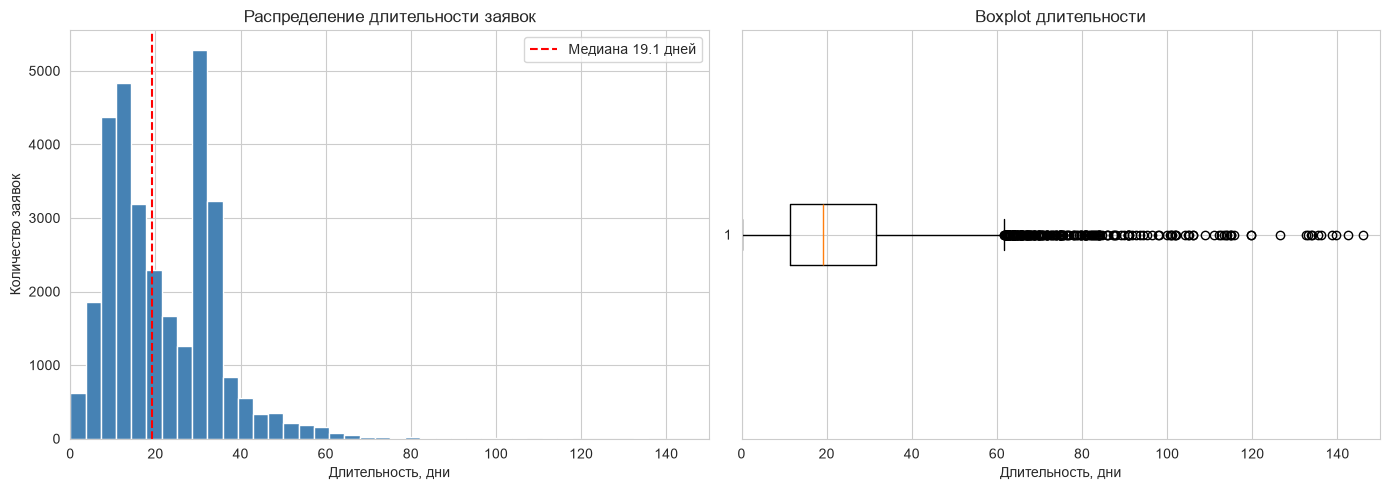

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(case_summary['duration_days'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Длительность, дни')
axes[0].set_ylabel('Количество заявок')
axes[0].set_title('Распределение длительности заявок')
axes[0].axvline(case_summary['duration_days'].median(), color='red', linestyle='--',
                label=f"Медиана {case_summary['duration_days'].median():.1f} дней")
axes[0].legend()
axes[0].set_xlim(0, 150)

axes[1].boxplot(case_summary['duration_days'], orientation='horizontal')
axes[1].set_xlabel('Длительность, дни')
axes[1].set_title('Boxplot длительности')
axes[1].set_xlim(0, 150)

plt.tight_layout()
plt.savefig('../assets/duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Реальная воронка процесса:
                  Этап  Заявок  Доля от старта, %
        Заявка создана   31509              100.0
Отправлена на проверку   20423               64.8
             Валидация   21870               69.4
          Оффер создан   31509              100.0
       Оффер отправлен   31050               98.5
          Оффер принят   17228               54.7
      Заявка завершена   31362               99.5


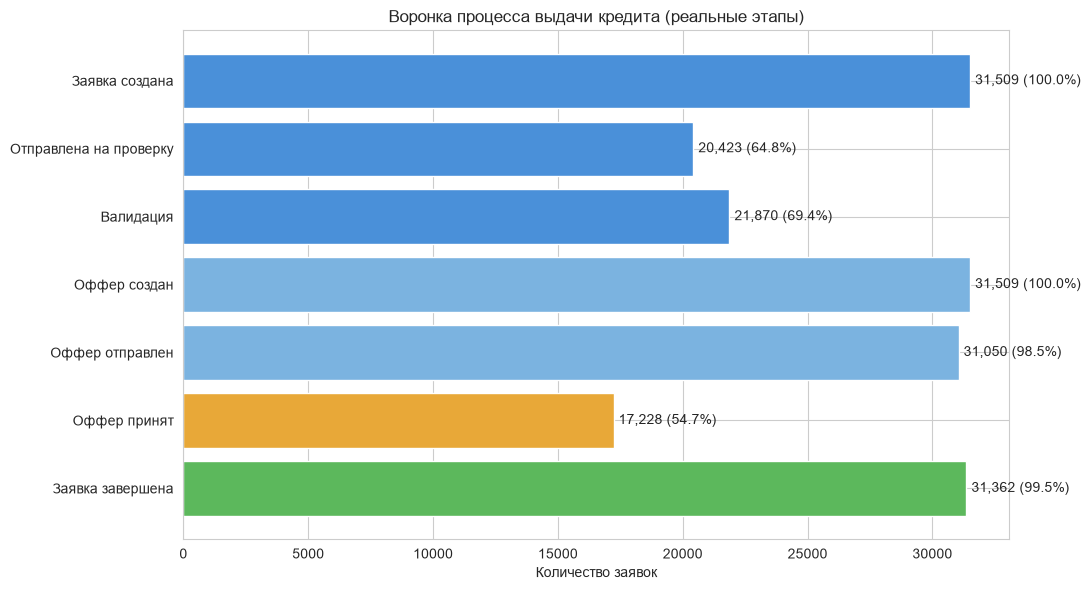

In [7]:
stages_order = [
    ('Заявка создана', 'A_Create Application'),
    ('Отправлена на проверку', 'A_Submitted'),
    ('Валидация', 'A_Validating'),
    ('Оффер создан', 'O_Created'),
    ('Оффер отправлен', 'O_Sent (mail and online)'),
    ('Оффер принят', 'O_Accepted'),
    ('Заявка завершена', 'A_Complete'),
]

funnel = []
for label, activity in stages_order:
    n = df[df['activity'] == activity]['case_id'].nunique()
    funnel.append({'Этап': label, 'Заявок': n})

funnel_df = pd.DataFrame(funnel)
funnel_df['Доля от старта, %'] = (funnel_df['Заявок'] / funnel_df['Заявок'].iloc[0] * 100).round(1)

print("Реальная воронка процесса:")
print(funnel_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#4a90d9', '#4a90d9', '#4a90d9', '#7bb3e0', '#7bb3e0', '#e8a838', '#5cb85c']
bars = ax.barh(funnel_df['Этап'], funnel_df['Заявок'], color=colors)
ax.set_xlabel('Количество заявок')
ax.set_title('Воронка процесса выдачи кредита (реальные этапы)')
ax.invert_yaxis()
for bar, val, pct in zip(bars, funnel_df['Заявок'], funnel_df['Доля от старта, %']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct}%)', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../assets/funnel.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:

offers = df.groupby('case_id').agg(
    requested_amount=('requested_amount', 'max'),
    offered_amount=('OfferedAmount', 'max'),
    credit_score=('CreditScore', 'max'),
    monthly_cost=('MonthlyCost', 'max'),
    accepted=('Accepted', 'max'),
    selected=('Selected', 'max')
).reset_index()

offers = offers.dropna(subset=['offered_amount', 'requested_amount'])
offers['ratio'] = offers['offered_amount'] / offers['requested_amount']

print(f"Заявок с обеими суммами: {len(offers):,}")
print()
print(f"Соотношение offered/requested:")
print(offers['ratio'].describe().round(3))
print()
print(f"Оффер меньше запрошенной суммы:  {(offers['ratio'] < 0.99).mean() * 100:.1f}%")
print(f"Оффер больше запрошенной суммы:  {(offers['ratio'] > 1.01).mean() * 100:.1f}%")
print(f"Оффер примерно равен запрошенной: {(offers['ratio'].between(0.99, 1.01)).mean() * 100:.1f}%")
print()
print(f"Средний CreditScore: {offers['credit_score'].mean():.0f}")
print(f"Доля Accepted == 1:  {(offers['accepted'] == 1).mean() * 100:.1f}%")
print(f"Доля Selected == 1:  {(offers['selected'] == 1).mean() * 100:.1f}%")

Заявок с обеими суммами: 31,509

Соотношение offered/requested:
count    31509.000
mean           inf
std            NaN
min          0.099
25%          1.000
50%          1.000
75%          1.000
max            inf
Name: ratio, dtype: float64

Оффер меньше запрошенной суммы:  7.0%
Оффер больше запрошенной суммы:  21.3%
Оффер примерно равен запрошенной: 71.7%

Средний CreditScore: 435
Доля Accepted == 1:  73.0%
Доля Selected == 1:  69.1%


/Users/tatiana/Documents/process-analytics/loan-process-analytics/venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [9]:

sent = df[df['activity'] == 'O_Sent (mail and online)'][['case_id', 'timestamp']].rename(
    columns={'timestamp': 'sent_time'})
accepted = df[df['activity'] == 'O_Accepted'][['case_id', 'timestamp']].rename(
    columns={'timestamp': 'accept_time'})
cancelled = df[df['activity'] == 'O_Cancelled'][['case_id', 'timestamp']].rename(
    columns={'timestamp': 'cancel_time'})

sent = sent.groupby('case_id').first().reset_index()
accepted = accepted.groupby('case_id').first().reset_index()
cancelled = cancelled.groupby('case_id').first().reset_index()

merged = sent.merge(accepted, on='case_id', how='left').merge(cancelled, on='case_id', how='left')

merged['days_to_accept'] = (merged['accept_time'] - merged['sent_time']).dt.total_seconds() / 86400
merged['days_to_cancel'] = (merged['cancel_time'] - merged['sent_time']).dt.total_seconds() / 86400

print("Время от отправки оффера до принятия:")
print(merged['days_to_accept'].describe().round(2))
print()
print("Время от отправки оффера до отмены:")
print(merged['days_to_cancel'].describe().round(2))

Время от отправки оффера до принятия:
count    17038.00
mean        16.78
std         10.99
min          0.02
25%          9.14
50%         13.78
75%         20.90
max        145.91
Name: days_to_accept, dtype: float64

Время от отправки оффера до отмены:
count    15446.00
mean        24.14
std         14.00
min        -27.06
25%         12.94
50%         30.56
75%         30.82
max        167.16
Name: days_to_cancel, dtype: float64


In [10]:

offers = df.groupby('case_id').agg(
    requested_amount=('requested_amount', 'max'),
    offered_amount=('OfferedAmount', 'max'),
    credit_score=('CreditScore', 'max'),
    monthly_cost=('MonthlyCost', 'max'),
    accepted=('Accepted', 'max'),
    selected=('Selected', 'max')
).reset_index()

offers = offers.dropna(subset=['offered_amount', 'requested_amount'])
offers = offers[offers['requested_amount'] > 0]
offers['ratio'] = offers['offered_amount'] / offers['requested_amount']

print(f"Заявок с обеими суммами: {len(offers):,}")
print()
print(f"Соотношение offered/requested:")
print(offers['ratio'].describe().round(3))
print()
print(f"Оффер меньше запрошенной суммы:  {(offers['ratio'] < 0.99).mean() * 100:.1f}%")
print(f"Оффер больше запрошенной суммы:  {(offers['ratio'] > 1.01).mean() * 100:.1f}%")
print(f"Оффер примерно равен запрошенной: {(offers['ratio'].between(0.99, 1.01)).mean() * 100:.1f}%")
print()
print(f"Средний CreditScore: {offers['credit_score'].mean():.0f}")
print(f"Доля Accepted == 1:  {(offers['accepted'] == 1).mean() * 100:.1f}%")
print(f"Доля Selected == 1:  {(offers['selected'] == 1).mean() * 100:.1f}%")

Заявок с обеими суммами: 28,429

Соотношение offered/requested:
count    28429.000
mean         1.062
std          0.507
min          0.099
25%          1.000
50%          1.000
75%          1.000
max         15.000
Name: ratio, dtype: float64

Оффер меньше запрошенной суммы:  7.8%
Оффер больше запрошенной суммы:  12.7%
Оффер примерно равен запрошенной: 79.5%

Средний CreditScore: 433
Доля Accepted == 1:  72.7%
Доля Selected == 1:  68.3%


In [11]:
def time_between(log_df, act_from, act_to):
    a = log_df[log_df['activity'] == act_from].groupby('case_id')['timestamp'].min()
    b = log_df[log_df['activity'] == act_to].groupby('case_id')['timestamp'].min()
    delta = (b - a).dt.total_seconds() / 86400
    return delta.dropna()

transitions = [
    ('A_Submitted', 'A_Validating', 'Подача → Валидация'),
    ('A_Validating', 'A_Pending', 'Валидация → Ожидание решения'),
    ('O_Sent (mail and online)', 'O_Accepted', 'Отправка оффера → Принятие'),
    ('O_Sent (mail and online)', 'O_Cancelled', 'Отправка оффера → Отмена'),
]

rows = []
for act_from, act_to, label in transitions:
    d = time_between(df, act_from, act_to)
    if len(d) > 0:
        rows.append({
            'Переход': label,
            'Заявок': len(d),
            'Медиана, дней': round(d.median(), 2),
            'Среднее, дней': round(d.mean(), 2),
            '90-й перцентиль': round(d.quantile(0.9), 2),
        })

transition_df = pd.DataFrame(rows)
print("Длительность переходов между этапами:")
print(transition_df.to_string(index=False))

Длительность переходов между этапами:
                     Переход  Заявок  Медиана, дней  Среднее, дней  90-й перцентиль
          Подача → Валидация   13333           9.93          12.37            22.11
Валидация → Ожидание решения   17228           4.96           6.99            16.75
  Отправка оффера → Принятие   17038          13.78          16.78            30.81
    Отправка оффера → Отмена   15446          30.56          24.14            33.87


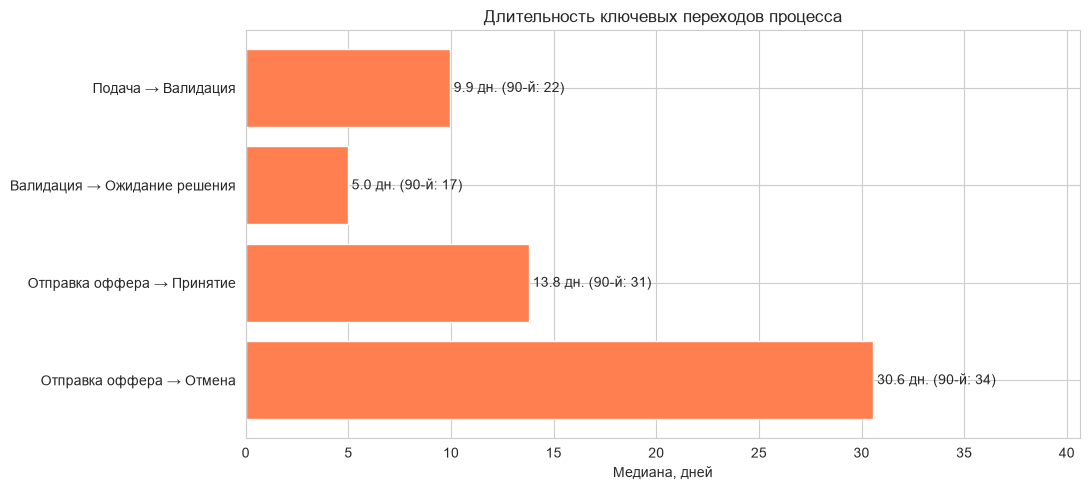

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(transition_df['Переход'], transition_df['Медиана, дней'], color='coral')
ax.set_xlabel('Медиана, дней')
ax.set_title('Длительность ключевых переходов процесса')
ax.invert_yaxis()
for bar, val, q90 in zip(bars, transition_df['Медиана, дней'], transition_df['90-й перцентиль']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} дн. (90-й: {q90:.0f})', va='center', fontsize=10)
plt.xlim(0, transition_df['90-й перцентиль'].max() * 1.2)
plt.tight_layout()
plt.savefig('../assets/transitions.png', dpi=150, bbox_inches='tight')
plt.show()

## Схема процесса

На схеме показаны реальные этапы и исходы. Сумма долей «принят» и «отменён» превышает 100%, потому что часть заявок проходила через несколько офферов: один отменялся, следом создавался новый, и клиент принимал уже его.

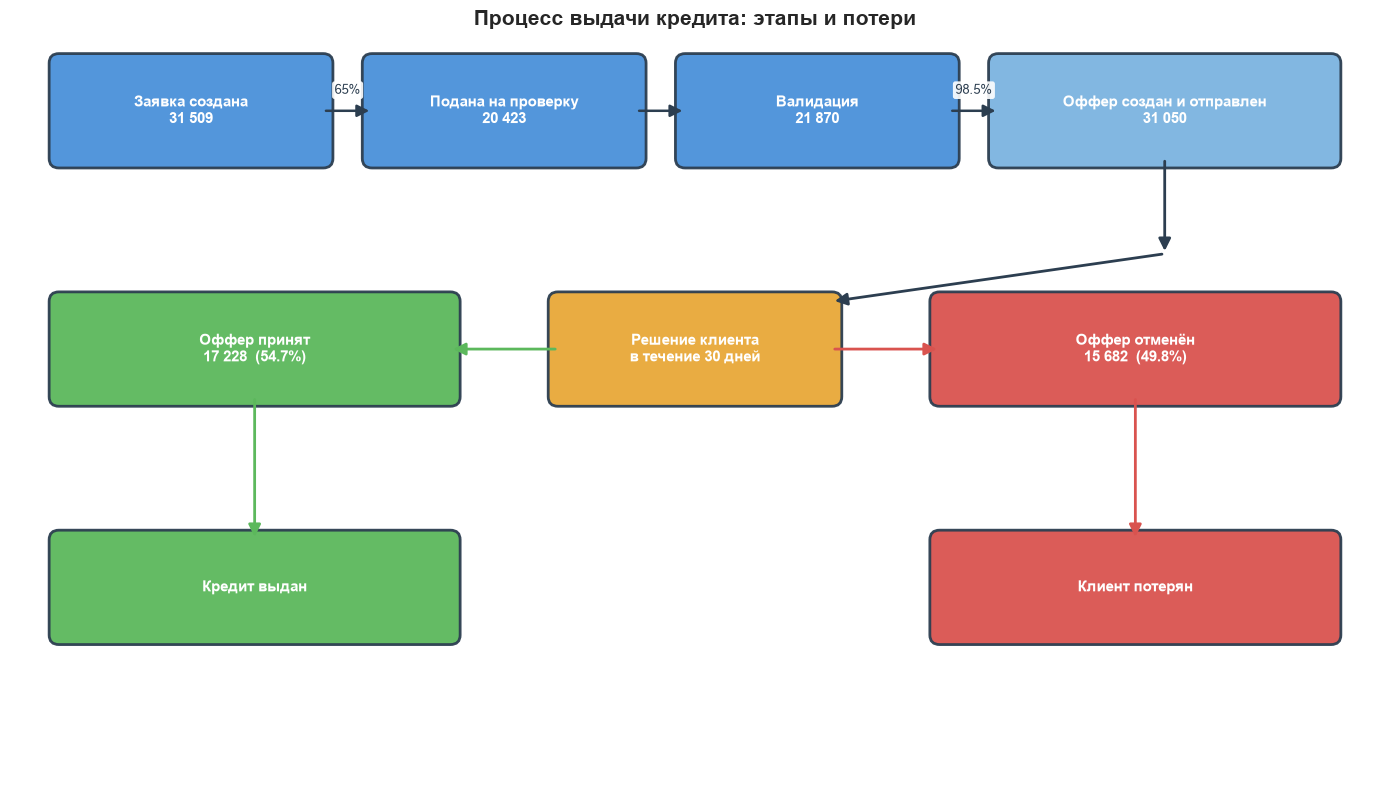

Сохранено: assets/process_flow.png


In [25]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')

def draw_box(x, y, w, h, text, color='#4a90d9'):
    box = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.1",
                          linewidth=2, edgecolor='#2c3e50',
                          facecolor=color, alpha=0.95)
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

def draw_arrow(x1, y1, x2, y2, label='', color='#2c3e50', lw=1.8):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                             arrowstyle='-|>', mutation_scale=18,
                             linewidth=lw, color=color)
    ax.add_patch(arrow)
    if label:
        ax.text((x1 + x2)/2, (y1 + y2)/2 + 0.15, label,
                ha='center', va='bottom', fontsize=9, color=color,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='none', alpha=0.9))

draw_box(0.5, 6.5, 2.7, 1.0, 'Заявка создана\n31 509', '#4a90d9')
draw_box(3.7, 6.5, 2.7, 1.0, 'Подана на проверку\n20 423', '#4a90d9')
draw_box(6.9, 6.5, 2.7, 1.0, 'Валидация\n21 870', '#4a90d9')
draw_box(10.1, 6.5, 3.4, 1.0, 'Оффер создан и отправлен\n31 050', '#7bb3e0')

draw_arrow(3.2, 7.0, 3.7, 7.0, '65%')
draw_arrow(6.4, 7.0, 6.9, 7.0, '')
draw_arrow(9.6, 7.0, 10.1, 7.0, '98.5%')

draw_box(5.6, 4.0, 2.8, 1.0, 'Решение клиента\nв течение 30 дней', '#e8a838')

draw_arrow(11.8, 6.5, 11.8, 5.5, '', color='#2c3e50', lw=2)
draw_arrow(11.8, 5.5, 8.4, 5.0, '', color='#2c3e50', lw=2)

draw_box(0.5, 4.0, 4.0, 1.0, 'Оффер принят\n17 228  (54.7%)', '#5cb85c')
draw_box(9.5, 4.0, 4.0, 1.0, 'Оффер отменён\n15 682  (49.8%)', '#d9534f')

draw_arrow(5.6, 4.5, 4.5, 4.5, '', color='#5cb85c', lw=2)
draw_arrow(8.4, 4.5, 9.5, 4.5, '', color='#d9534f', lw=2)

draw_box(0.5, 1.5, 4.0, 1.0, 'Кредит выдан', '#5cb85c')
draw_box(9.5, 1.5, 4.0, 1.0, 'Клиент потерян', '#d9534f')

draw_arrow(2.5, 4.0, 2.5, 2.5, '', color='#5cb85c', lw=2)
draw_arrow(11.5, 4.0, 11.5, 2.5, '', color='#d9534f', lw=2)

ax.text(7, 7.9, 'Процесс выдачи кредита: этапы и потери',
        ha='center', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/process_flow.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: assets/process_flow.png")

## Результаты и выводы

**Длительность.** Медиана обработки заявки — 19 дней, среднее — 22 дня, максимум — 286 дней. Треть заявок закрывается дольше 31 дня.

**Воронка.** От заявки до принятия оффера доходят 54.7% клиентов. Остальные 45% теряются на этапе ожидания решения.

**Узкие места:**
1. Валидация документов — медиана 9.9 дней
2. Ожидание решения клиента — медиана 13.8 дней
3. Автоматическая отмена оффера через 30 дней без ответа

**Схема процесса** показывает ключевую точку потерь: оффер отправлен 31 050 заявкам, принят — 17 228. Разрыв в 13 822 заявки.

**Рекомендации:**
- Автоматизировать первичную валидацию документов
- Добавить follow-up напоминания клиентам на 7-й, 14-й и 21-й день после отправки оффера
- Сократить срок автоотмены с 30 до 21 дня для неактивных заявок